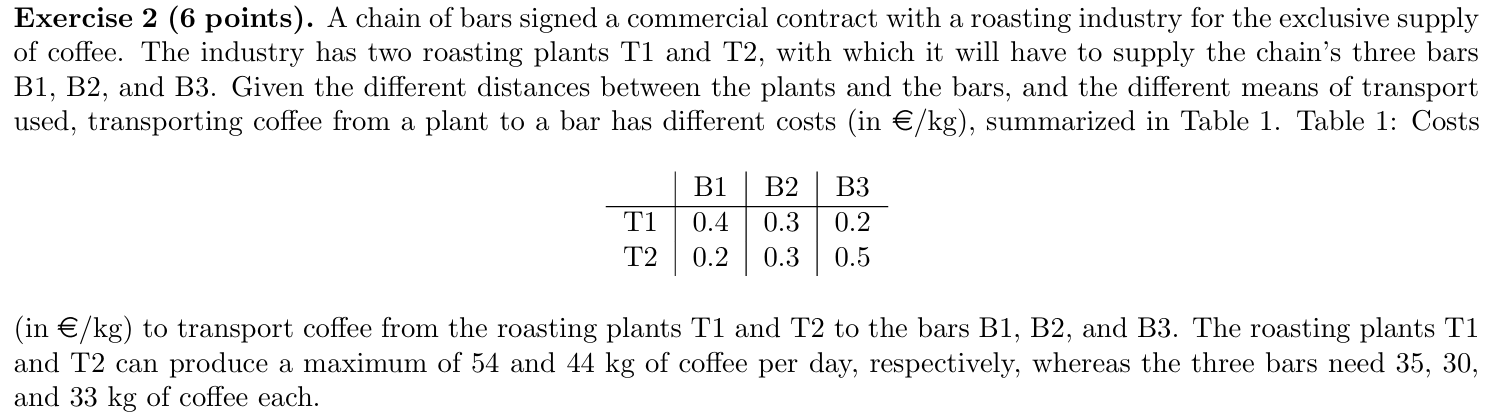

**Indexes**:
- $i$ : plant
- $j$ : bar

**Parameters**:
- $C_{i,j}$ = transport cost €/kg
- $M_i$ : maximum production of plant i
- $D_j$ : demand bar j

**Variables**:
- $x_{i,j}$ = amount of coffe (kg) from i to j

$$ min \ \ \sum_i \sum_j x_{i,j} C_{i,j}$$
$$ s.t \sum_j x_{i,j} \le M_i \ \ \forall i $$
$$ \sum_i x_{i,j} \ge D_j $$
$$ x_{i,j} \ge 0$$

In [4]:
import gurobipy as gp
from gurobipy import GRB

m = gp.Model("coffee_transport_optimization")

# PARAMETERS
plants = ["Plant1", "Plant2"] 
bars = ["Bar1", "Bar2", "Bar3"]

# Costi di trasporto C_{i,j} (in un dizionario con chiavi a tupla (impianto, bar))
costi = {
    ("Plant1", "Bar1"): 0.4, ("Plant1", "Bar2"): 0.3, ("Plant1", "Bar3"): 0.2,
    ("Plant2", "Bar1"): 0.2, ("Plant2", "Bar2"): 0.3, ("Plant2", "Bar3"): 0.5
}

# Massima produzione M_i
produzione_max = {
    "Plant1": 54,
    "Plant2": 44
}

# Domanda dei bar D_j
domanda = {
    "Bar1": 35,
    "Bar2": 30,
    "Bar3": 33
}

# VARIABLES

x = m.addVars(plants, bars, vtype=GRB.CONTINUOUS, name="x")


# CONSTRAINTS

# Vincolo di produzione massima (Supply constraints): sum_j x_{i,j} <= M_i per ogni i
for i in plants:
    m.addConstr(gp.quicksum(x[i, j] for j in bars) <= produzione_max[i], name=f"Max_Prod_{i}")

# Vincolo di soddisfacimento della domanda (Demand constraints): sum_i x_{i,j} >= D_j per ogni j
for j in bars:
    m.addConstr(gp.quicksum(x[i, j] for i in plants) >= domanda[j], name=f"Domanda_{j}")


# OBJECTIVE FUNCTION

m.setObjective(gp.quicksum(x[i, j] * costi[i, j] for i in plants for j in bars), GRB.MINIMIZE)

# RISOLUZIONE
m.optimize()

# OUTPUT DEI RISULTATI
print("-" * 30)
if m.status == GRB.OPTIMAL:
    print(f"Stato Ottimizzazione: OTTIMO TROVATO")
    print(f"Costo Totale Minimo di Trasporto: {m.objVal} euro")
    print("\nPiano di Trasporto Ottimo:")
    
    # Stampo solo le tratte dove spedisco effettivamente qualcosa (x > 0)
    for i in plants:
        for j in bars:
            if x[i, j].x > 0.01:  # Ignora i valori a zero e i piccolissimi errori numerici del PC
                print(f"- Da {i} a {j}: spedire {x[i, j].x} kg")
else:
    print("Nessuna soluzione ottima trovata. (Assicurati che la Produzione Totale sia >= della Domanda Totale)")


Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: 13th Gen Intel(R) Core(TM) i7-13620H, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 5 rows, 6 columns and 12 nonzeros (Min)
Model fingerprint: 0x4faaae79
Model has 6 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e-01, 5e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+01, 5e+01]

Presolve time: 0.01s
Presolved: 5 rows, 6 columns, 12 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   9.800000e+01   0.000000e+00      0s
       4    2.2600000e+01   0.000000e+00   0.000000e+00      0s

Solved in 4 iterations and 0.01 seconds (0.00 work units)
Optimal objective  2.260000000e+01
------------------------------
Stato Ottimizzazione: OTTIMO TROVATO
Costo Totale Minimo di Trasporto: 22.59999